<a href="https://colab.research.google.com/github/pakizahassan/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pakizahassan/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (Scoring)

Lane is Refresh / Content Opportunity Scoring. This is a scoring task because the goal is to assign each webpage a score that represents how strongly it should be considered for a content refresh. Higher scores indicate higher priority for updating the content.

In [26]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*


Target: Content Opportunity Score

The model predicts a content opportunity score for each webpage. This score can be based on observed website performance indicators such as declining traffic, lower engagement, outdated content, or other measurable signals. It acts as a proxy for refresh priority.

In [27]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Success metric

*One metric you can defend. What number means 'good'?*

Metric: Mean Absolute Error (MAE)

A lower MAE indicates that the predicted content opportunity scores are close to the expected values. Since this is a scoring task, MAE is an appropriate metric for evaluating prediction accuracy.

In [28]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

Each row in the dataset represents one webpage. Each webpage contains information such as traffic, engagement, freshness, keywords, or other SEO-related features that help determine whether the content should be refreshed.

In [29]:
!git clone https://github.com/pakizahassan/flyrank-ml-internship.git

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv("/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv")

In [32]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [33]:
# Display columns and data information

print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  -------

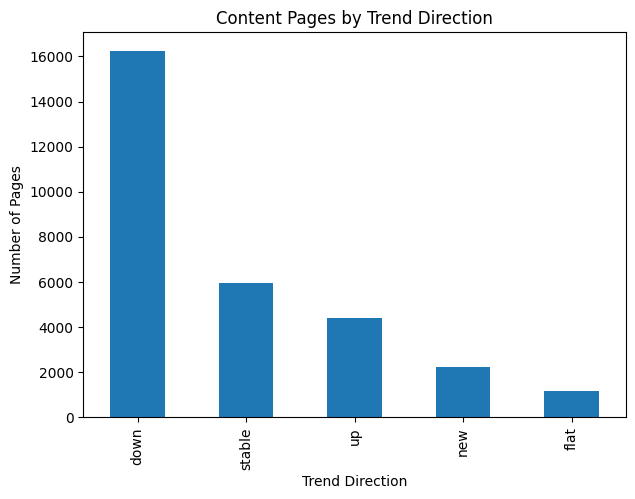

In [34]:
plt.figure(figsize=(7,5))

df["trend_direction"].value_counts().plot(kind="bar")

plt.title("Content Pages by Trend Direction")
plt.xlabel("Trend Direction")
plt.ylabel("Number of Pages")

plt.show()

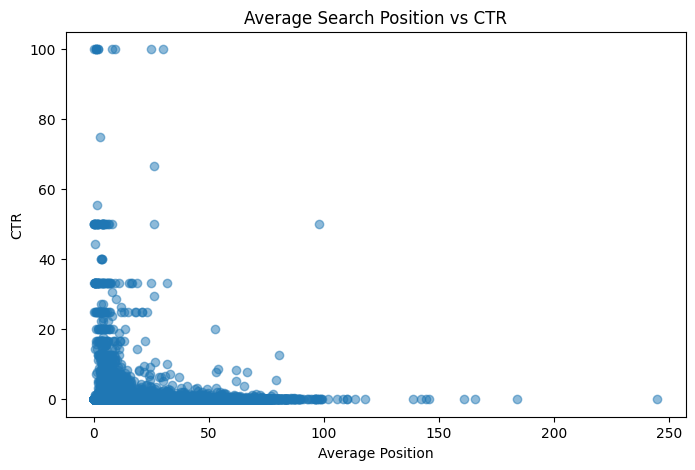

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["avg_position"],
    df["ctr"],
    alpha=0.5
)

plt.title("Average Search Position vs CTR")
plt.xlabel("Average Position")
plt.ylabel("CTR")

plt.show()

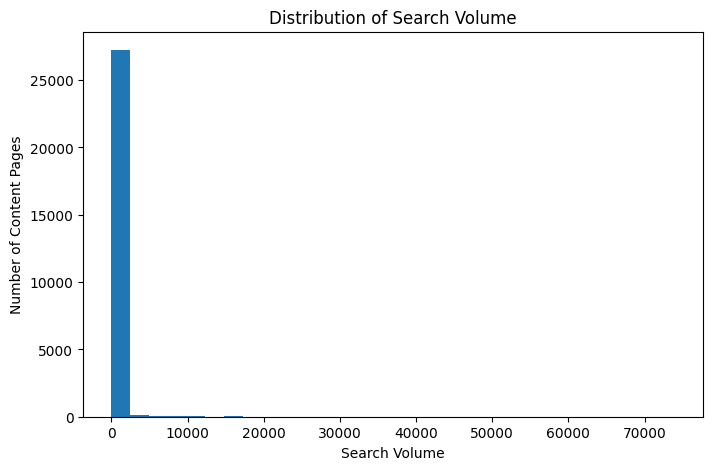

In [36]:
plt.figure(figsize=(8,5))

plt.hist(
    df["search_volume"].dropna(),
    bins=30
)

plt.title("Distribution of Search Volume")
plt.xlabel("Search Volume")
plt.ylabel("Number of Content Pages")

plt.show()

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

A fixed rule-based approach cannot capture the complexity of content performance. For example, refreshing every page with declining traffic may ignore important factors such as search demand, ranking position, competition, and user engagement.

Content opportunity depends on multiple signals working together. Machine learning can learn patterns from historical content performance data and combine different features to generate a better refresh priority score.


In [37]:
# Select important numerical features for analysis

features = [
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "trend_pct"
]

# Show correlation between features

df[features].corr()

,search_volume,ctr,avg_position,engagement_rate,scroll_rate,trend_pct
search_volume,1.000000,-0.003430,0.045354,-0.010146,-0.013808,0.002515
ctr,-0.003430,1.000000,-0.072590,0.096903,0.012955,0.007968
avg_position,0.045354,-0.072590,1.000000,-0.017926,-0.039757,0.047248
engagement_rate,-0.010146,0.096903,-0.017926,1.000000,0.162611,0.008412
scroll_rate,-0.013808,0.012955,-0.039757,0.162611,1.000000,0.001868
trend_pct,0.002515,0.007968,0.047248,0.008412,0.001868,1.000000


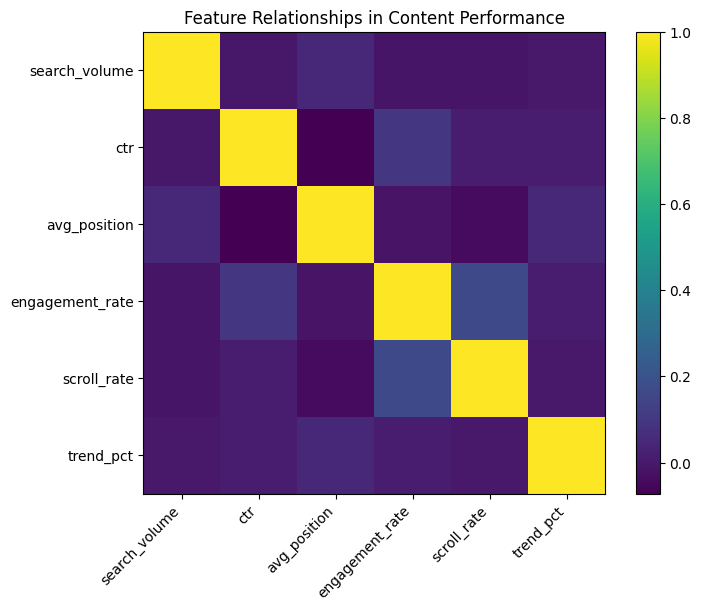

In [38]:
import matplotlib.pyplot as plt

corr = df[features].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(features)),
    features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(features)),
    features
)

plt.title("Feature Relationships in Content Performance")

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.